<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/ZomatoDeliveryTimePrediction/blob/main/02Modeling_zd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Delivery Time Prediction — 02: Modeling

Covers: load prepared data from Drive, shared preprocessing pipeline, baselines, classical
regression models, comparison table, Optuna tuning, feature-group ablation experiments.

In [1]:
!git clone https://github.com/narendrapatel6321-dotcom/ZomatoDeliveryTimePrediction.git
import sys
sys.path.append("/content/ZomatoDeliveryTimePrediction/src")

Cloning into 'ZomatoDeliveryTimePrediction'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 738.34 KiB | 4.34 MiB/s, done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/zomato-delivery-time-prediction"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Mounted at /content/drive


In [3]:
import json

df = pd.read_parquet(f"{DRIVE_OUTPUT_DIR}/prepared_data.parquet")

with open(f"{DRIVE_OUTPUT_DIR}/feature_metadata.json") as f:
    metadata = json.load(f)

target_col = metadata["target_col"]
print(f"Loaded: {df.shape}")
print(f"Target: {target_col}")

Loaded: (45584, 36)
Target: Time_taken (min)


In [4]:
train_df = df[df["split_random"] == "train"]
val_df = df[df["split_random"] == "val"]
test_df = df[df["split_random"] == "test"]

X_train, y_train = train_df, train_df[target_col]
X_val, y_val = val_df, val_df[target_col]
X_test, y_test = test_df, test_df[target_col]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 31908, Val: 6838, Test: 6838


## Preprocessing Pipeline

Shared ColumnTransformer from `src/preprocessing.py`. Two variants: scaled (linear models),
unscaled (tree-based models).

In [5]:
from preprocessing import build_preprocessor

preprocessor_scaled = build_preprocessor(scale_numeric=True)
preprocessor_unscaled = build_preprocessor(scale_numeric=False)

# Fit on train, confirm it runs end-to-end and check output shape
X_train_transformed = preprocessor_scaled.fit_transform(X_train)
print(f"Transformed train shape: {X_train_transformed.shape}")
print(f"Output feature count: {X_train_transformed.shape[1]}")

Transformed train shape: (31908, 52)
Output feature count: 52


## Baseline Models

In [6]:
from eval_utils import compute_metrics

mean_pred = np.full_like(y_val, y_train.mean(), dtype=float)
median_pred = np.full_like(y_val, y_train.median(), dtype=float)

baseline_results = {
    "Mean Baseline": {"metrics": compute_metrics(y_val, mean_pred), "train_time_sec": 0.0},
    "Median Baseline": {"metrics": compute_metrics(y_val, median_pred), "train_time_sec": 0.0},
}
baseline_results

{'Mean Baseline': {'metrics': {'MAE': 7.685808484637557,
   'RMSE': np.float64(9.507550795065015),
   'R2': -1.8045895848750604e-06,
   'MedAE': np.float64(6.710636830888806),
   'within_5min_pct': np.float64(37.62796139221995),
   'within_10min_pct': np.float64(68.1339572974554)},
  'train_time_sec': 0.0},
 'Median Baseline': {'metrics': {'MAE': 7.657794676806084,
   'RMSE': np.float64(9.512341700808145),
   'R2': -0.001009871036085741,
   'MedAE': np.float64(7.0),
   'within_5min_pct': np.float64(41.079262942380815),
   'within_10min_pct': np.float64(71.87774202983329)},
  'train_time_sec': 0.0}}

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Deliberately tiny feature set — distance and traffic only, per plan Section 10.
# (prep_time excluded here too, same leakage reasoning as the main feature set)
simple_preprocessor = ColumnTransformer([
    ("dist", SimpleImputer(strategy="median"), ["distance_km"]),
    ("traffic", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), ["Road_traffic_density"]),
])

simple_baseline = Pipeline([
    ("preprocess", simple_preprocessor),
    ("model", LinearRegression()),
])

start = time.time()
simple_baseline.fit(X_train, y_train)
train_time = time.time() - start

simple_pred = simple_baseline.predict(X_val)
baseline_results["Distance+Traffic Baseline"] = {
    "metrics": compute_metrics(y_val, simple_pred),
    "train_time_sec": train_time,
}

from eval_utils import build_comparison_table
build_comparison_table(baseline_results)

,Model,MAE,RMSE,R2,MedAE,within_5min_pct,within_10min_pct,Training Time (s)
0,Distance+Traffic Baseline,6.683945,8.358721,0.227065,5.624701,45.159403,76.703715,0.052832
1,Median Baseline,7.657795,9.512342,-0.001010,7.000000,41.079263,71.877742,0.000000
2,Mean Baseline,7.685808,9.507551,-0.000002,6.710637,37.627961,68.133957,0.000000


## Classical Regression Models

In [8]:
!pip install xgboost --quiet

In [10]:
from sklearn.linear_model import LinearRegression, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from preprocessing import build_preprocessor
import numpy as np

# (model, needs_scaling) — linear-family gets the scaled preprocessor, tree-based gets unscaled
# Ridge/ElasticNet use *CV variants so alpha isn't left at library default (1.0, which over-regularizes
# ElasticNet in particular). Boosting methods matched on training budget (n_estimators=300,
# learning_rate=0.05) so no model wins purely from a more generous default schedule.
models = {
    "Linear Regression": (LinearRegression(), True),
    "Ridge": (RidgeCV(alphas=np.logspace(-3, 3, 13)), True),
    "ElasticNet": (ElasticNetCV(cv=5, random_state=RANDOM_SEED, n_jobs=-1), True),
    "Random Forest": (RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_leaf=1,
        random_state=RANDOM_SEED, n_jobs=-1
    ), False),
    "Gradient Boosting": (GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8,
        random_state=RANDOM_SEED
    ), False),
    "HistGradientBoosting": (HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=None, max_leaf_nodes=31,
        random_state=RANDOM_SEED
    ), False),
    "XGBoost": (XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, n_jobs=-1
    ), False),
}

model_results = dict(baseline_results)  # keep baselines in the same table for comparison
fitted_pipelines = {}

for name, (model, scale) in models.items():
    pipeline = Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=scale)),
        ("model", model),
    ])
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    val_pred = pipeline.predict(X_val)
    model_results[name] = {"metrics": compute_metrics(y_val, val_pred), "train_time_sec": train_time}
    fitted_pipelines[name] = pipeline
    print(f"{name} done in {train_time:.1f}s")

    # Surface what CV actually picked, since it replaces a fixed default
    if name == "Ridge":
        print(f"  RidgeCV chosen alpha: {model.alpha_:.4f}")
    if name == "ElasticNet":
        print(f"  ElasticNetCV chosen alpha: {model.alpha_:.4f}, l1_ratio: {model.l1_ratio_:.4f}")

comparison_table = build_comparison_table(model_results)
comparison_table

Linear Regression done in 0.2s
Ridge done in 0.5s
  RidgeCV chosen alpha: 3.1623
ElasticNet done in 4.5s
  ElasticNetCV chosen alpha: 0.0070, l1_ratio: 0.5000
Random Forest done in 71.7s
Gradient Boosting done in 27.8s
HistGradientBoosting done in 3.7s
XGBoost done in 3.6s


,Model,MAE,RMSE,R2,MedAE,within_5min_pct,within_10min_pct,Training Time (s)
0,Random Forest,3.223234,4.086084,0.815295,2.735000,79.847909,98.113483,71.735902
1,XGBoost,3.231298,4.056744,0.817938,2.795845,79.789412,98.391342,3.588574
2,HistGradientBoosting,3.231316,4.055017,0.818093,2.793464,80.272009,98.288973,3.673415
3,Gradient Boosting,3.323892,4.169465,0.807680,2.880410,78.590231,98.142732,27.833583
4,Linear Regression,4.840134,6.074197,0.591830,4.161977,58.686751,90.640538,0.235021
5,Ridge,4.840263,6.074414,0.591801,4.162017,58.730623,90.625914,0.523412
6,ElasticNet,4.860174,6.100261,0.588320,4.176326,58.379643,90.450424,4.515340
7,Distance+Traffic Baseline,6.683945,8.358721,0.227065,5.624701,45.159403,76.703715,0.052832
8,Median Baseline,7.657795,9.512342,-0.001010,7.000000,41.079263,71.877742,0.000000
9,Mean Baseline,7.685808,9.507551,-0.000002,6.710637,37.627961,68.133957,0.000000


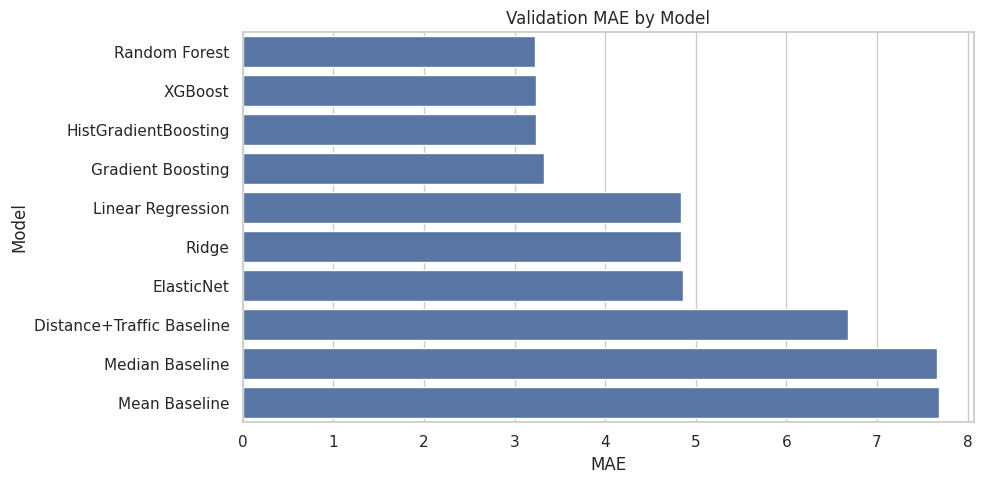

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=comparison_table, x="MAE", y="Model", ax=ax)
ax.set_title("Validation MAE by Model")
plt.tight_layout()
plt.show()

## Checkpoint: Save Model Comparison to Drive

In [12]:
import pickle
import os

os.makedirs(f"{DRIVE_OUTPUT_DIR}/models", exist_ok=True)

comparison_table.to_csv(f"{DRIVE_OUTPUT_DIR}/model_comparison.csv", index=False)

with open(f"{DRIVE_OUTPUT_DIR}/models/fitted_pipelines.pkl", "wb") as f:
    pickle.dump(fitted_pipelines, f)

print("Saved comparison table and fitted pipelines to Drive.")

Saved comparison table and fitted pipelines to Drive.


## Hyperparameter Optimization (Optuna)

Tuning XGBoost and HistGradientBoosting only (Random Forest dropped — near-identical MAE to these
two but ~20x slower to train, poor Optuna ROI). Objective: minimize validation MAE. Test set stays
untouched until final evaluation, per plan Section 15.

In [13]:
!pip install optuna --quiet
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep trial-by-trial spam out of the output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 13.4 MB/s eta 0:00:00


In [15]:
from xgboost import XGBRegressor
from preprocessing import build_preprocessor
from eval_utils import compute_metrics

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
    }

    pipeline = Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False)),
        ("model", XGBRegressor(**params)),
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    return compute_metrics(y_val, val_pred)["MAE"]

xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"Best XGBoost MAE: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best XGBoost MAE: 3.1582
Best params: {'n_estimators': 491, 'max_depth': 10, 'learning_rate': 0.01797343955251045, 'min_child_weight': 2, 'subsample': 0.8244563609172214, 'colsample_bytree': 0.8561714454419305, 'reg_alpha': 0.006129358552529108, 'reg_lambda': 2.732392881504184, 'gamma': 0.013055171512827313}


In [16]:
from sklearn.ensemble import HistGradientBoostingRegressor

def histgb_objective(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 127),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        "random_state": RANDOM_SEED,
    }

    pipeline = Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False)),
        ("model", HistGradientBoostingRegressor(**params)),
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    return compute_metrics(y_val, val_pred)["MAE"]

histgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
histgb_study.optimize(histgb_objective, n_trials=100, show_progress_bar=True)

print(f"Best HistGB MAE: {histgb_study.best_value:.4f}")
print(f"Best params: {histgb_study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best HistGB MAE: 3.1597
Best params: {'max_iter': 628, 'max_depth': 15, 'learning_rate': 0.0604064471721583, 'max_leaf_nodes': 117, 'min_samples_leaf': 8, 'l2_regularization': 3.1174887732650745}


## Optimization History and Parameter Importance

/tmp/ipykernel_1372/2897592295.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_viz.plot_optimization_history(xgb_study)


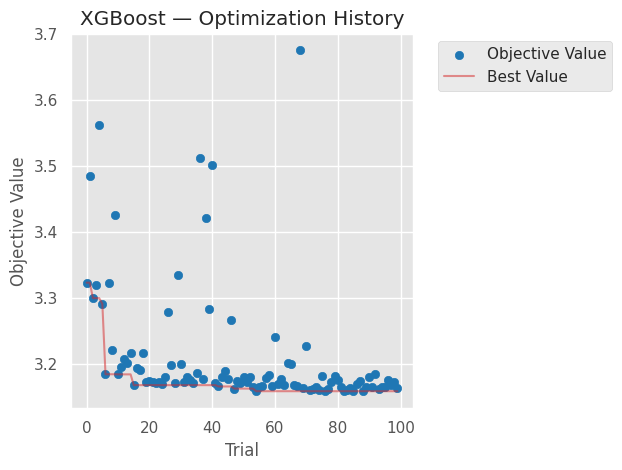

/tmp/ipykernel_1372/2897592295.py:8: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_viz.plot_param_importances(xgb_study)


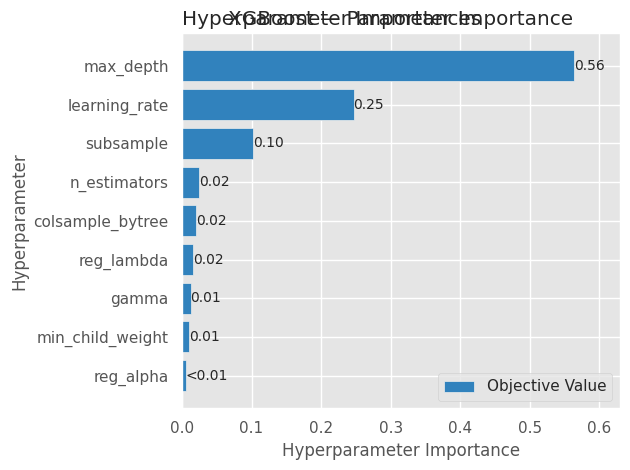

/tmp/ipykernel_1372/2897592295.py:13: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_viz.plot_optimization_history(histgb_study)


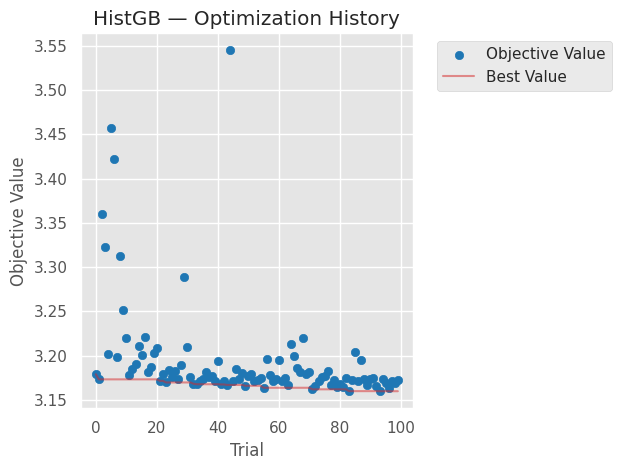

/tmp/ipykernel_1372/2897592295.py:18: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_viz.plot_param_importances(histgb_study)


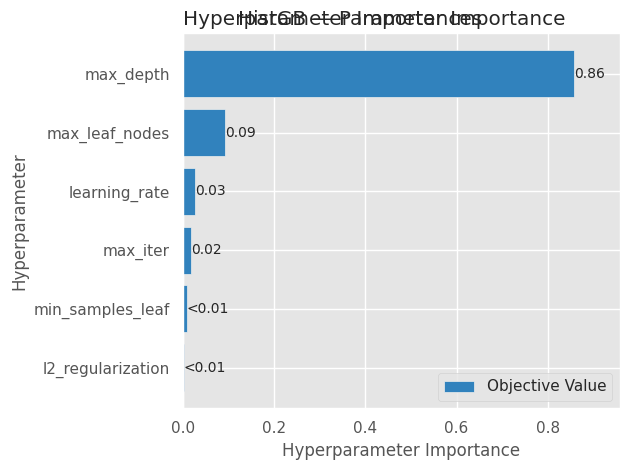

In [19]:
import optuna.visualization.matplotlib as optuna_viz

optuna_viz.plot_optimization_history(xgb_study)
plt.title("XGBoost — Optimization History")
plt.tight_layout()
plt.show()

optuna_viz.plot_param_importances(xgb_study)
plt.title("XGBoost — Parameter Importance")
plt.tight_layout()
plt.show()

optuna_viz.plot_optimization_history(histgb_study)
plt.title("HistGB — Optimization History")
plt.tight_layout()
plt.show()

optuna_viz.plot_param_importances(histgb_study)
plt.title("HistGB — Parameter Importance")
plt.tight_layout()
plt.show()

## Finalize Tuned Models

In [20]:
best_xgb = Pipeline([
    ("preprocess", build_preprocessor(scale_numeric=False)),
    ("model", XGBRegressor(**xgb_study.best_params, random_state=RANDOM_SEED, n_jobs=-1)),
])
start = time.time()
best_xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start

best_histgb = Pipeline([
    ("preprocess", build_preprocessor(scale_numeric=False)),
    ("model", HistGradientBoostingRegressor(**histgb_study.best_params, random_state=RANDOM_SEED)),
])
start = time.time()
best_histgb.fit(X_train, y_train)
histgb_train_time = time.time() - start

model_results["XGBoost (tuned)"] = {
    "metrics": compute_metrics(y_val, best_xgb.predict(X_val)), "train_time_sec": xgb_train_time
}
model_results["HistGB (tuned)"] = {
    "metrics": compute_metrics(y_val, best_histgb.predict(X_val)), "train_time_sec": histgb_train_time
}
fitted_pipelines["XGBoost (tuned)"] = best_xgb
fitted_pipelines["HistGB (tuned)"] = best_histgb

comparison_table = build_comparison_table(model_results)
comparison_table

,Model,MAE,RMSE,R2,MedAE,within_5min_pct,within_10min_pct,Training Time (s)
0,XGBoost (tuned),3.158238,3.971084,0.825546,2.698172,81.222580,98.552208,8.702531
1,HistGB (tuned),3.159692,3.970710,0.825579,2.705000,81.105586,98.479087,3.343955
2,Random Forest,3.223234,4.086084,0.815295,2.735000,79.847909,98.113483,71.735902
3,XGBoost,3.231298,4.056744,0.817938,2.795845,79.789412,98.391342,3.588574
4,HistGradientBoosting,3.231316,4.055017,0.818093,2.793464,80.272009,98.288973,3.673415
5,Gradient Boosting,3.323892,4.169465,0.807680,2.880410,78.590231,98.142732,27.833583
6,Linear Regression,4.840134,6.074197,0.591830,4.161977,58.686751,90.640538,0.235021
7,Ridge,4.840263,6.074414,0.591801,4.162017,58.730623,90.625914,0.523412
8,ElasticNet,4.860174,6.100261,0.588320,4.176326,58.379643,90.450424,4.515340
9,Distance+Traffic Baseline,6.683945,8.358721,0.227065,5.624701,45.159403,76.703715,0.052832


## Feature Engineering Experiments

Per plan Section 16 — isolate the marginal value of each feature group. Same model config
(untuned, fixed HistGB) across every experiment so differences reflect the features, not
hyperparameter luck. Cumulative: each experiment adds to the previous one.

- A: Raw features only (no engineered geo/temporal/interaction features)
- B: A + geographic (distance_km, coords_corrupted)
- C: B + temporal (order_hour, order_day_of_week, order_month, is_weekend, order_period, is_peak_hour)
- D: C + interaction features (distance × traffic severity, distance × bad weather)
- E: Full set == D (this is what the main model comparison above already used, minus interactions —
  so D tells us whether interactions are worth adding to the "final" feature set)

In [24]:
train_df = df[df["split_random"] == "train"].copy()
val_df = df[df["split_random"] == "val"].copy()
test_df = df[df["split_random"] == "test"].copy()

traffic_severity_map = {"Low": 1, "Medium": 2, "High": 3, "Jam": 4}

for split in [train_df, val_df, test_df]:
    split["traffic_severity"] = split["Road_traffic_density"].map(traffic_severity_map)
    split["distance_x_traffic"] = split["distance_km"] * split["traffic_severity"]
    split["weather_bad"] = (~split["Weather_conditions"].isin(["Sunny"])).astype(int)
    split["distance_x_weather_bad"] = split["distance_km"] * split["weather_bad"]

X_train, y_train = train_df, train_df[target_col]
X_val, y_val = val_df, val_df[target_col]
X_test, y_test = test_df, test_df[target_col]

display(train_df[["traffic_severity", "distance_x_traffic", "weather_bad", "distance_x_weather_bad"]].head())

,traffic_severity,distance_x_traffic,weather_bad,distance_x_weather_bad
2,2.0,27.575720,1,13.787860
3,1.0,2.930258,1,2.930258
5,4.0,55.055909,1,13.763977
6,3.0,18.654004,1,6.218001
8,4.0,43.028435,1,10.757109


In [25]:
def build_ablation_preprocessor(numeric_cols, categorical_cols, include_city=True):
    transformers = [
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True))]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_cols),
    ]
    if include_city:
        transformers.append((
            "city",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            ["City"],
        ))
    return ColumnTransformer(transformers)


feature_groups = {
    "A_raw": {
        "numeric": ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition", "multiple_deliveries"],
        "categorical": ["Weather_conditions", "Road_traffic_density", "Type_of_order", "Type_of_vehicle", "Festival"],
    },
}
feature_groups["B_plus_geo"] = {
    "numeric": feature_groups["A_raw"]["numeric"] + ["distance_km", "coords_corrupted"],
    "categorical": feature_groups["A_raw"]["categorical"],
}
feature_groups["C_plus_temporal"] = {
    "numeric": feature_groups["B_plus_geo"]["numeric"] + [
        "order_hour", "order_day_of_week", "order_month", "is_weekend", "is_peak_hour"
    ],
    "categorical": feature_groups["B_plus_geo"]["categorical"] + ["order_period"],
}
feature_groups["D_plus_interaction"] = {
    "numeric": feature_groups["C_plus_temporal"]["numeric"] + [
        "traffic_severity", "distance_x_traffic", "weather_bad", "distance_x_weather_bad"
    ],
    "categorical": feature_groups["C_plus_temporal"]["categorical"],
}

In [26]:
ablation_results = {}

for exp_name, cols in feature_groups.items():
    preprocessor = build_ablation_preprocessor(cols["numeric"], cols["categorical"], include_city=True)
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_SEED)),
    ])
    pipeline.fit(X_train, y_train)
    val_pred = pipeline.predict(X_val)
    ablation_results[exp_name] = compute_metrics(y_val, val_pred)
    print(f"{exp_name}: MAE={ablation_results[exp_name]['MAE']:.4f}")

ablation_table = pd.DataFrame(ablation_results).T.sort_index()
ablation_table

A_raw: MAE=3.9690
B_plus_geo: MAE=3.2500
C_plus_temporal: MAE=3.2389
D_plus_interaction: MAE=3.2557


,MAE,RMSE,R2,MedAE,within_5min_pct,within_10min_pct
A_raw,3.968992,5.036261,0.719405,3.321273,69.918105,94.954665
B_plus_geo,3.249951,4.081246,0.815732,2.822175,79.672419,98.230477
C_plus_temporal,3.238878,4.064357,0.817254,2.807494,79.877157,98.332846
D_plus_interaction,3.255712,4.083180,0.815558,2.812714,79.453056,98.230477


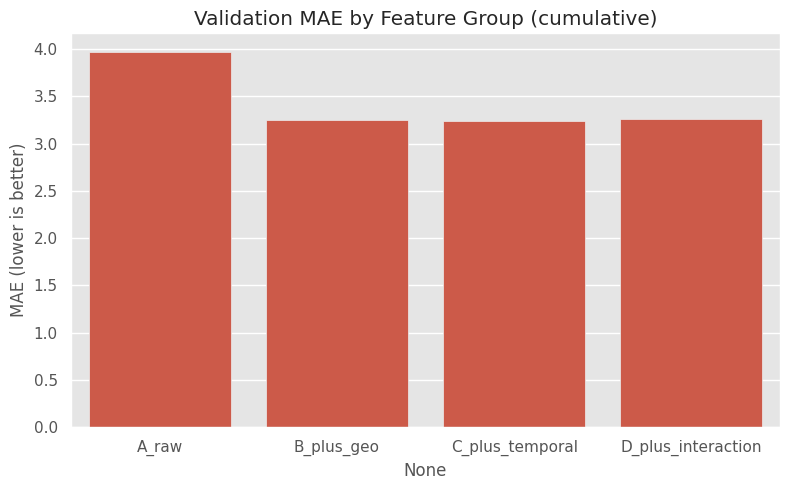

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=ablation_table.index, y=ablation_table["MAE"], ax=ax)
ax.set_title("Validation MAE by Feature Group (cumulative)")
ax.set_ylabel("MAE (lower is better)")
plt.tight_layout()
plt.show()

## Notebook 2 Summary

- **Baselines beaten decisively**: Mean/median (~7.7 MAE) → Distance+Traffic (6.68) → best tuned
  tree model (3.158).
- **Model comparison (fair hyperparameters, not defaults)**: 4 tree-based models cluster tightly
  (MAE 3.22–3.32), linear models cluster separately (~4.84–4.86). Random Forest dropped from
  Optuna tuning — tied top MAE but ~20x slower to train than XGBoost/HistGB for no real gain.
- **Optuna tuning**: XGBoost 3.231 → 3.158 MAE, HistGB 3.231 → 3.160 MAE (both ~2.2-2.3% improvement).
  Essentially tied post-tuning — **both carried forward into notebook 3**, final single-model
  decision deferred until SHAP/residual analysis is visible.
- **Feature-group ablation**: geographic features are the dominant lever (18.4% relative MAE
  reduction alone). Temporal adds a small genuine gain. Hand-crafted interaction features
  (distance×traffic, distance×weather) made results marginally *worse* — trees already capture
  these interactions implicitly through splits. **Final feature set = raw + geographic + temporal,
  no explicit interaction terms.**
- **Test set untouched throughout** — reserved for notebook 3's final evaluation once the model
  choice is settled.

In [28]:
import pickle
import json

# Ablation results — evidence for the "why these features" writeup in the README
ablation_table.to_csv(f"{DRIVE_OUTPUT_DIR}/feature_ablation_results.csv")

# Final comparison table (baselines + all 7 fair-hyperparameter models + 2 tuned models)
comparison_table.to_csv(f"{DRIVE_OUTPUT_DIR}/model_comparison_final.csv", index=False)

# Both tuned candidate pipelines — decision on which becomes "the" final model happens in notebook 3
with open(f"{DRIVE_OUTPUT_DIR}/models/tuned_candidates.pkl", "wb") as f:
    pickle.dump({
        "XGBoost (tuned)": fitted_pipelines["XGBoost (tuned)"],
        "HistGB (tuned)": fitted_pipelines["HistGB (tuned)"],
    }, f)

# Record of what was tried and decided, so notebook 3 doesn't need to re-derive context
modeling_metadata = {
    "final_feature_groups": "raw + geographic + temporal (no interaction terms — see ablation)",
    "excluded_interaction_features": ["traffic_severity", "distance_x_traffic", "weather_bad", "distance_x_weather_bad"],
    "models_dropped_from_tuning": ["Random Forest — tied top MAE, ~20x slower to train"],
    "xgb_best_params": xgb_study.best_params,
    "xgb_best_val_mae": xgb_study.best_value,
    "histgb_best_params": histgb_study.best_params,
    "histgb_best_val_mae": histgb_study.best_value,
    "final_model_decision": "deferred to notebook 3 — pending SHAP/residual analysis",
    "test_set_status": "untouched",
}
with open(f"{DRIVE_OUTPUT_DIR}/modeling_metadata.json", "w") as f:
    json.dump(modeling_metadata, f, indent=2)

print("Saved: ablation table, final comparison table, both tuned pipelines, modeling metadata")

Saved: ablation table, final comparison table, both tuned pipelines, modeling metadata
